# Stage 8: Simulation Results

This notebook summarizes Stage 8 outputs from `results/simulation` for the available feature-selection methods.

It includes:
- data coverage and schema checks
- numeric summary tables (recall/FDR)
- plots by signal type, effect size, and top-k setting

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "simulation").exists() and (candidate / "src").exists():
            return candidate
    return start


ROOT = find_repo_root(Path.cwd())
RESULTS_ROOT = ROOT / "results" / "simulation"
METHODS = ["ttest", "random"]

frames = []
meta_rows = []

for method in METHODS:
    results_path = RESULTS_ROOT / method / "results.parquet"
    meta_path = RESULTS_ROOT / method / "meta.json"

    if not results_path.exists():
        print(f"[WARN] Missing results for method='{method}': {results_path}")
        continue

    df_method = pd.read_parquet(results_path).copy()
    df_method["method"] = method
    frames.append(df_method)

    if meta_path.exists():
        meta = json.loads(meta_path.read_text(encoding="utf-8"))
        meta_rows.append(
            {
                "method": method,
                "n_rows_meta": meta.get("n_rows"),
                "n_repeats": meta.get("n_repeats"),
                "n_features": meta.get("n_features"),
                "signals_per_type": meta.get("signals_per_type"),
                "effect_sizes": ", ".join(map(str, meta.get("effect_sizes", []))),
                "topk_values": ", ".join(map(str, meta.get("topk_values", []))),
                "includes_native": meta.get("includes_native"),
                "runtime_seconds": meta.get("runtime_seconds"),
            }
        )

if not frames:
    raise FileNotFoundError(f"No simulation result files found under {RESULTS_ROOT}")

results = pd.concat(frames, ignore_index=True)
results["k"] = results["k"].astype(str)

k_order = ["10", "25", "50", "100", "native"]
signal_order = ["linear", "saturation", "threshold", "u_shape", "xor_pair"]

results["k"] = pd.Categorical(results["k"], categories=k_order, ordered=True)
results["signal_type"] = pd.Categorical(results["signal_type"], categories=signal_order, ordered=True)

print(f"Detected project root: {ROOT}")
print(f"Loaded rows: {len(results):,}")
results.head()

Detected project root: c:\Programmering\exjobb\MSc26_Proteomics
Loaded rows: 7,500


,repeat,signal_type,effect_size,k,recall,fdr,method
0,1,linear,0.3,10,0.000000,0.000000,ttest
1,1,linear,0.3,100,1.000000,0.460000,ttest
2,1,linear,0.3,25,0.333333,0.040000,ttest
3,1,linear,0.3,50,1.000000,0.240000,ttest
4,1,linear,0.3,native,0.666667,0.035714,ttest


In [3]:
meta_df = pd.DataFrame(meta_rows).set_index("method") if meta_rows else pd.DataFrame()

coverage = (
    results.groupby("method", observed=False)
    .agg(
        n_rows=("repeat", "size"),
        repeats=("repeat", "nunique"),
        signal_types=("signal_type", "nunique"),
        effect_sizes=("effect_size", "nunique"),
        k_values=("k", "nunique"),
    )
    .sort_index()
)

print("Meta summary")
display(meta_df)

print("Observed data coverage")
display(coverage)

if not meta_df.empty:
    compare_rows = coverage.join(meta_df[["n_rows_meta"]], how="left")
    compare_rows["row_count_matches_meta"] = compare_rows["n_rows"] == compare_rows["n_rows_meta"]
    print("Row count validation")
    display(compare_rows)

Meta summary


,n_rows_meta,n_repeats,n_features,signals_per_type,effect_sizes,topk_values,includes_native,runtime_seconds
method,,,,,,,,
ttest,3750,50,100,3,"0.3, 0.6, 1.0","10, 25, 50, 100",True,0.298314
random,3750,50,100,3,"0.3, 0.6, 1.0","10, 25, 50, 100",True,0.215128


Observed data coverage


,n_rows,repeats,signal_types,effect_sizes,k_values
method,,,,,
random,3750,50,5,3,5
ttest,3750,50,5,3,5


Row count validation


,n_rows,repeats,signal_types,effect_sizes,k_values,n_rows_meta,row_count_matches_meta
method,,,,,,,
random,3750,50,5,3,5,3750,True
ttest,3750,50,5,3,5,3750,True


In [4]:
summary_method_k = (
    results.groupby(["method", "k"], observed=False)
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        fdr_mean=("fdr", "mean"),
        fdr_std=("fdr", "std"),
    )
    .reset_index()
)

summary_method_k["recall_mean"] = summary_method_k["recall_mean"].round(3)
summary_method_k["recall_std"] = summary_method_k["recall_std"].round(3)
summary_method_k["fdr_mean"] = summary_method_k["fdr_mean"].round(3)
summary_method_k["fdr_std"] = summary_method_k["fdr_std"].round(3)

print("Mean/SD by method and k")
display(summary_method_k)

print("Recall mean pivot (k x method)")
display(summary_method_k.pivot(index="k", columns="method", values="recall_mean"))

print("FDR mean pivot (k x method)")
display(summary_method_k.pivot(index="k", columns="method", values="fdr_mean"))

Mean/SD by method and k


,method,k,recall_mean,recall_std,fdr_mean,fdr_std
0,random,10,0.097,0.159,0.466,0.173
1,random,25,0.242,0.230,0.457,0.088
2,random,50,0.503,0.263,0.451,0.046
3,random,100,1.000,0.000,0.460,0.000
4,random,native,0.294,0.241,0.451,0.082
5,ttest,10,0.222,0.391,0.000,0.000
6,ttest,25,0.531,0.465,0.038,0.032
7,ttest,50,0.724,0.359,0.292,0.040
8,ttest,100,1.000,0.000,0.460,0.000
9,ttest,native,0.520,0.469,0.033,0.036


Recall mean pivot (k x method)


method,random,ttest
k,,
10,0.097,0.222
25,0.242,0.531
50,0.503,0.724
100,1.000,1.000
native,0.294,0.520


FDR mean pivot (k x method)


method,random,ttest
k,,
10,0.466,0.000
25,0.457,0.038
50,0.451,0.292
100,0.460,0.460
native,0.451,0.033


In [5]:
summary_signal_effect_k = (
    results.groupby(["method", "signal_type", "effect_size", "k"], observed=False)
    .agg(recall_mean=("recall", "mean"), fdr_mean=("fdr", "mean"))
    .reset_index()
)

focus_native_25 = summary_signal_effect_k[summary_signal_effect_k["k"].isin(["25", "native"])].copy()
focus_native_25["recall_mean"] = focus_native_25["recall_mean"].round(3)
focus_native_25["fdr_mean"] = focus_native_25["fdr_mean"].round(3)

print("Signal/effect summary for k=25 vs native")
display(focus_native_25.head(30))

best_recall_by_signal = (
    summary_signal_effect_k.sort_values(["method", "signal_type", "effect_size", "recall_mean", "fdr_mean"], ascending=[True, True, True, False, True])
    .groupby(["method", "signal_type", "effect_size"], observed=False)
    .head(1)
    .rename(columns={"k": "best_k_by_recall"})
    .sort_values(["method", "signal_type", "effect_size"])
)

print("Best k by mean recall (tie-break: lower FDR)")
display(best_recall_by_signal[["method", "signal_type", "effect_size", "best_k_by_recall", "recall_mean", "fdr_mean"]])

Signal/effect summary for k=25 vs native


,method,signal_type,effect_size,k,recall_mean,fdr_mean
1,random,linear,0.3,25,0.227,0.457
4,random,linear,0.3,native,0.260,0.451
6,random,linear,0.6,25,0.227,0.457
9,random,linear,0.6,native,0.240,0.451
11,random,linear,1.0,25,0.207,0.457
14,random,linear,1.0,native,0.260,0.451
16,random,saturation,0.3,25,0.233,0.457
19,random,saturation,0.3,native,0.293,0.451
21,random,saturation,0.6,25,0.207,0.457
24,random,saturation,0.6,native,0.273,0.451


Best k by mean recall (tie-break: lower FDR)


,method,signal_type,effect_size,best_k_by_recall,recall_mean,fdr_mean
3,random,linear,0.3,100,1.0,0.460000
8,random,linear,0.6,100,1.0,0.460000
13,random,linear,1.0,100,1.0,0.460000
18,random,saturation,0.3,100,1.0,0.460000
23,random,saturation,0.6,100,1.0,0.460000
28,random,saturation,1.0,100,1.0,0.460000
33,random,threshold,0.3,100,1.0,0.460000
38,random,threshold,0.6,100,1.0,0.460000
43,random,threshold,1.0,100,1.0,0.460000
48,random,u_shape,0.3,100,1.0,0.460000


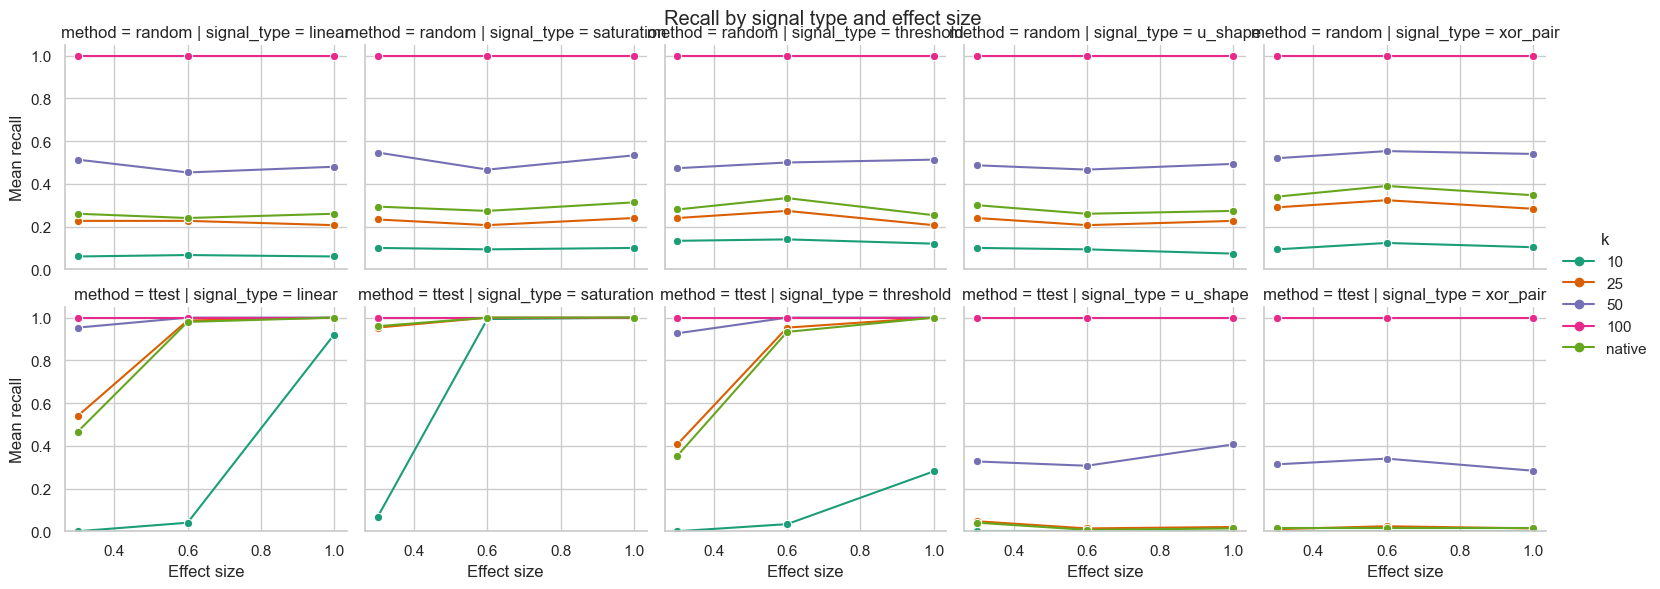

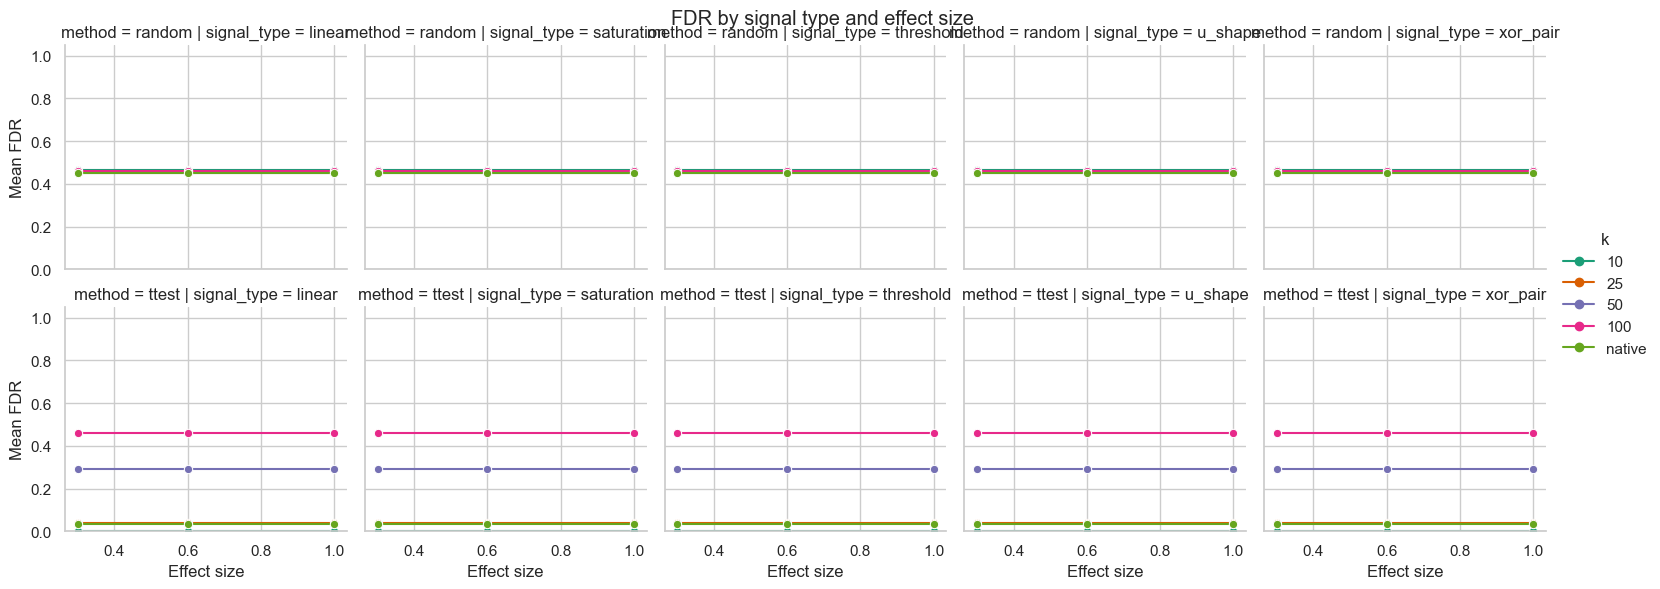

In [6]:
plot_df = (
    results.groupby(["method", "signal_type", "effect_size", "k"], observed=False)
    .agg(recall_mean=("recall", "mean"), fdr_mean=("fdr", "mean"))
    .reset_index()
)

palette = {
    "10": "#1b9e77",
    "25": "#d95f02",
    "50": "#7570b3",
    "100": "#e7298a",
    "native": "#66a61e",
}

g_recall = sns.relplot(
    data=plot_df,
    x="effect_size",
    y="recall_mean",
    hue="k",
    hue_order=k_order,
    col="signal_type",
    row="method",
    kind="line",
    marker="o",
    dashes=False,
    height=3.0,
    aspect=1.05,
    palette=palette,
)
g_recall.set(ylim=(0, 1.05))
g_recall.set_axis_labels("Effect size", "Mean recall")
g_recall.fig.subplots_adjust(top=0.92)
g_recall.fig.suptitle("Recall by signal type and effect size")
plt.show()

g_fdr = sns.relplot(
    data=plot_df,
    x="effect_size",
    y="fdr_mean",
    hue="k",
    hue_order=k_order,
    col="signal_type",
    row="method",
    kind="line",
    marker="o",
    dashes=False,
    height=3.0,
    aspect=1.05,
    palette=palette,
)
g_fdr.set(ylim=(0, 1.05))
g_fdr.set_axis_labels("Effect size", "Mean FDR")
g_fdr.fig.subplots_adjust(top=0.92)
g_fdr.fig.suptitle("FDR by signal type and effect size")
plt.show()

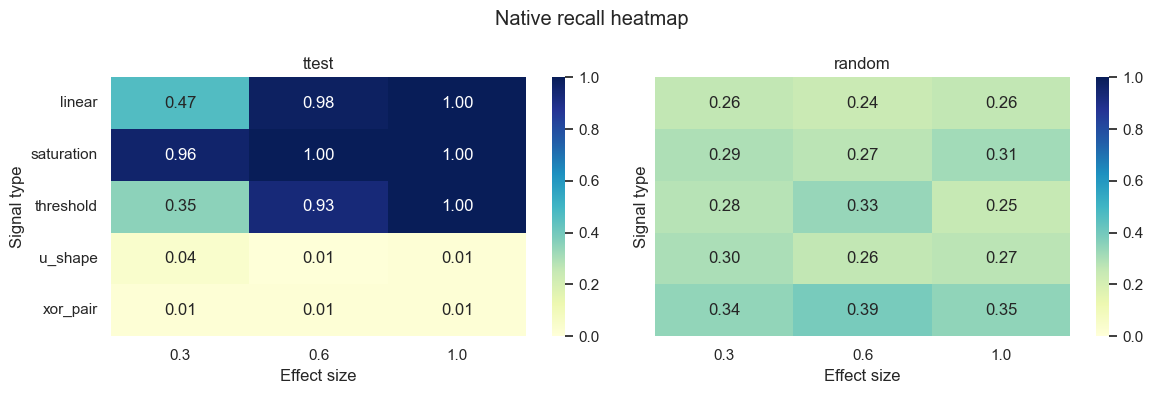

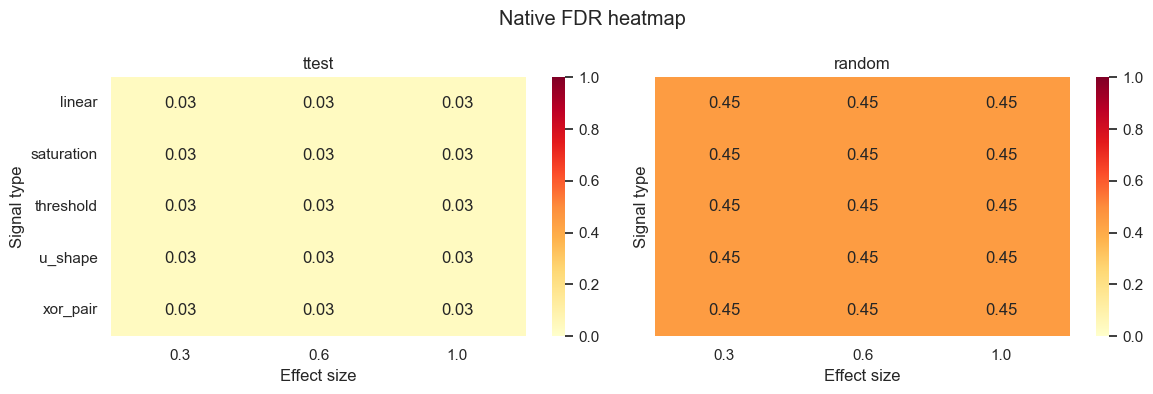

In [7]:
native_df = (
    results[results["k"] == "native"]
    .groupby(["method", "signal_type", "effect_size"], observed=False)
    .agg(recall_mean=("recall", "mean"), fdr_mean=("fdr", "mean"))
    .reset_index()
)

for metric, cmap, title in [
    ("recall_mean", "YlGnBu", "Native recall heatmap"),
    ("fdr_mean", "YlOrRd", "Native FDR heatmap"),
]:
    fig, axes = plt.subplots(1, len(METHODS), figsize=(12, 4), sharey=True)
    if len(METHODS) == 1:
        axes = [axes]

    for ax, method in zip(axes, METHODS):
        matrix = (
            native_df[native_df["method"] == method]
            .pivot(index="signal_type", columns="effect_size", values=metric)
            .reindex(signal_order)
        )
        sns.heatmap(
            matrix,
            annot=True,
            fmt=".2f",
            cmap=cmap,
            vmin=0.0,
            vmax=1.0,
            cbar=True,
            ax=ax,
        )
        ax.set_title(f"{method}")
        ax.set_xlabel("Effect size")
        ax.set_ylabel("Signal type")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

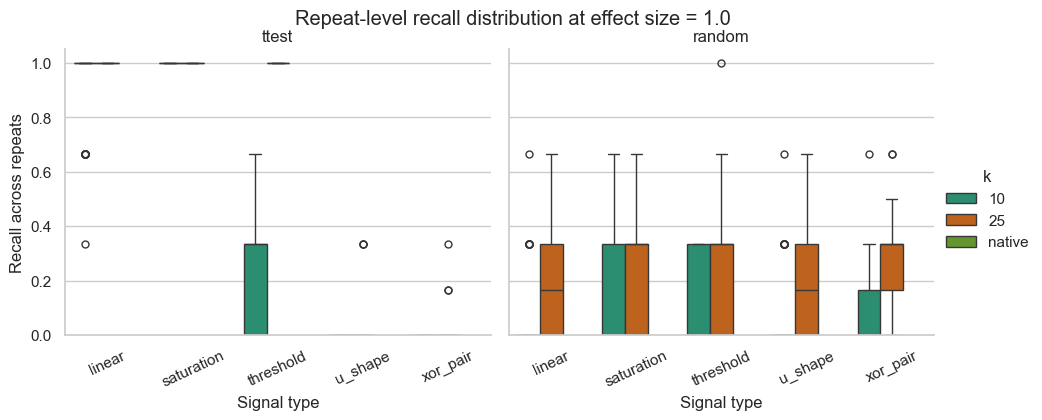

In [8]:
repeat_focus = results[(results["effect_size"] == 1.0) & (results["k"].isin(["10", "25", "native"]))].copy()

box = sns.catplot(
    data=repeat_focus,
    x="signal_type",
    y="recall",
    hue="k",
    hue_order=["10", "25", "native"],
    col="method",
    kind="box",
    height=4,
    aspect=1.2,
    palette=palette,
)
box.set_axis_labels("Signal type", "Recall across repeats")
box.set_titles("{col_name}")
box.fig.subplots_adjust(top=0.88)
box.fig.suptitle("Repeat-level recall distribution at effect size = 1.0")
for ax in box.axes.flat:
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=25)
plt.show()